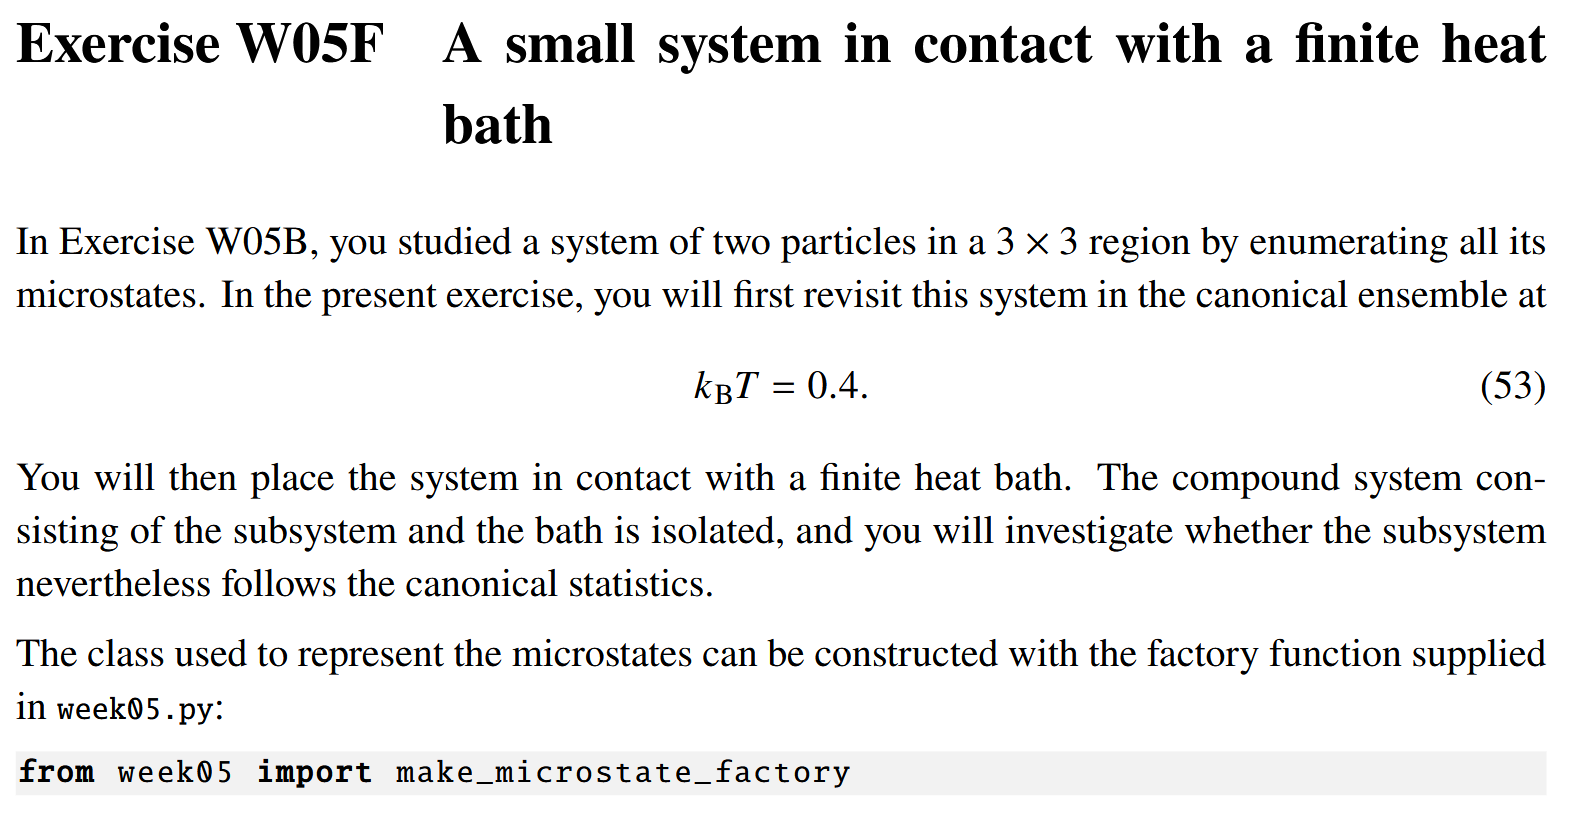
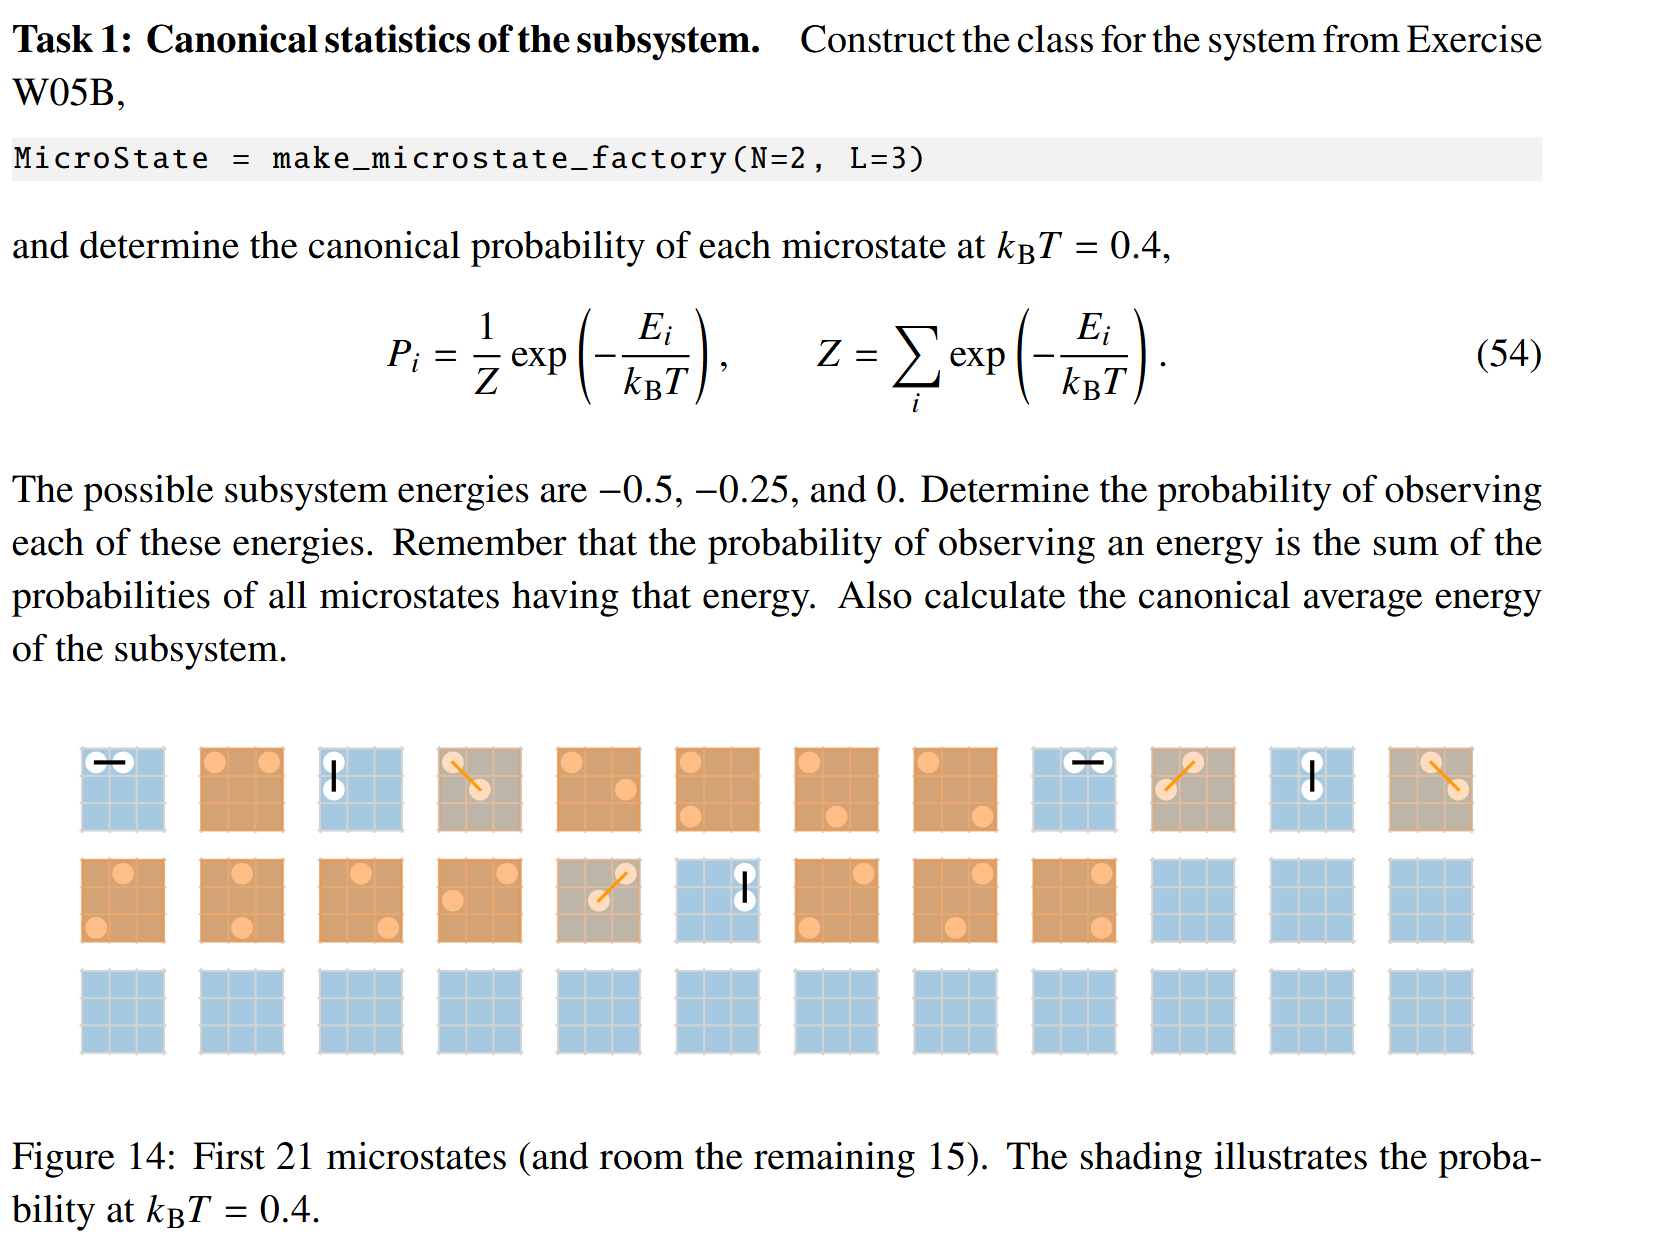

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from week05 import *

kbT = 0.4

MicroState = make_microstate_factory(2, 3)
energies = [MicroState(i).energy for i in range(MicroState.total)]

levels, counts = np.unique(energies, return_counts=True)

def canonical_energy(energy_levels, num_states, kbT):
    boltzmann_factors = np.exp(-energy_levels / (kbT))

    numerator = np.sum(energy_levels * num_states * boltzmann_factors)
    denominator = np.sum(num_states * boltzmann_factors)

    return (numerator / denominator)

boltzmann_factors = np.exp(-levels / kbT)
unnormalized_prob = counts * boltzmann_factors
probabilities = unnormalized_prob / np.sum(unnormalized_prob)

print(f'Probabilites: {probabilities} - Canonical average energy: {canonical_energy(levels, counts, kbT)}')

Probabilites: [0.57509361 0.20521695 0.21968944] - Canonical average energy: -0.33885104331333427


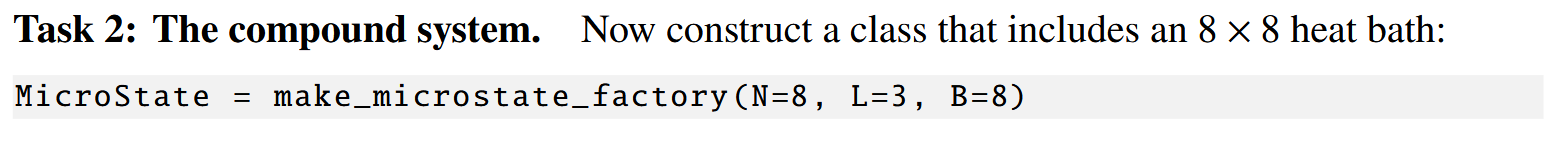
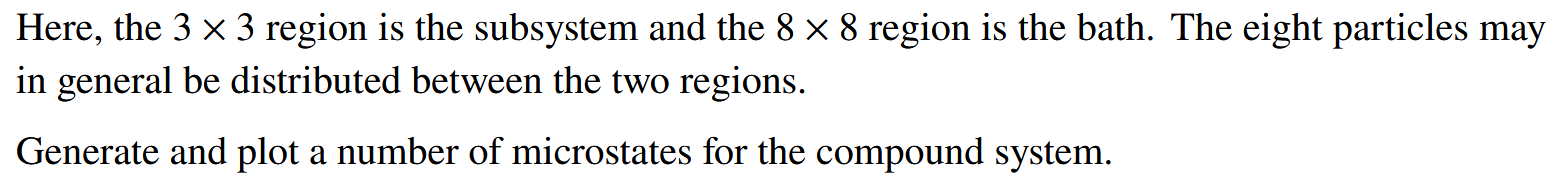
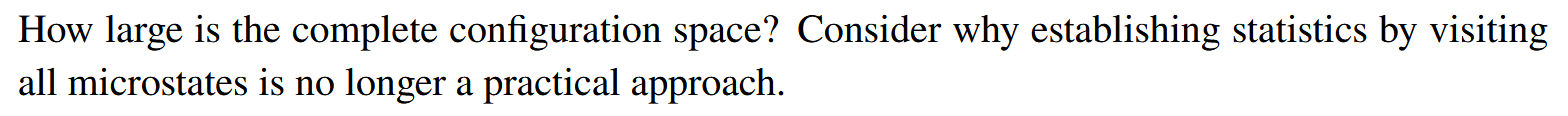

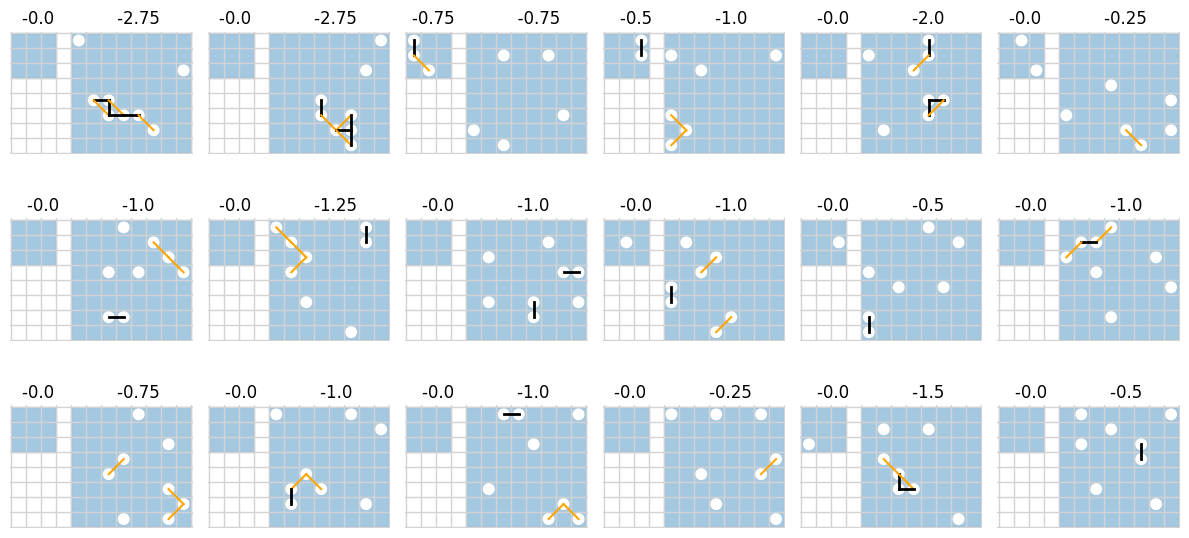

In [30]:
MicroState = make_microstate_factory(N=8, L=3, B=8)

fig, axes = plt.subplots(3, 6, figsize=(12, 6))

axes = axes.flatten()

for ax in axes:
    m = MicroState()
    m.plot(ax)
    ax.set_title(f'{m.subsystem_energy}            {m.energy}    ')
plt.tight_layout()

### The number of microstates is to large for int32, i had to change week05.py to use int64 

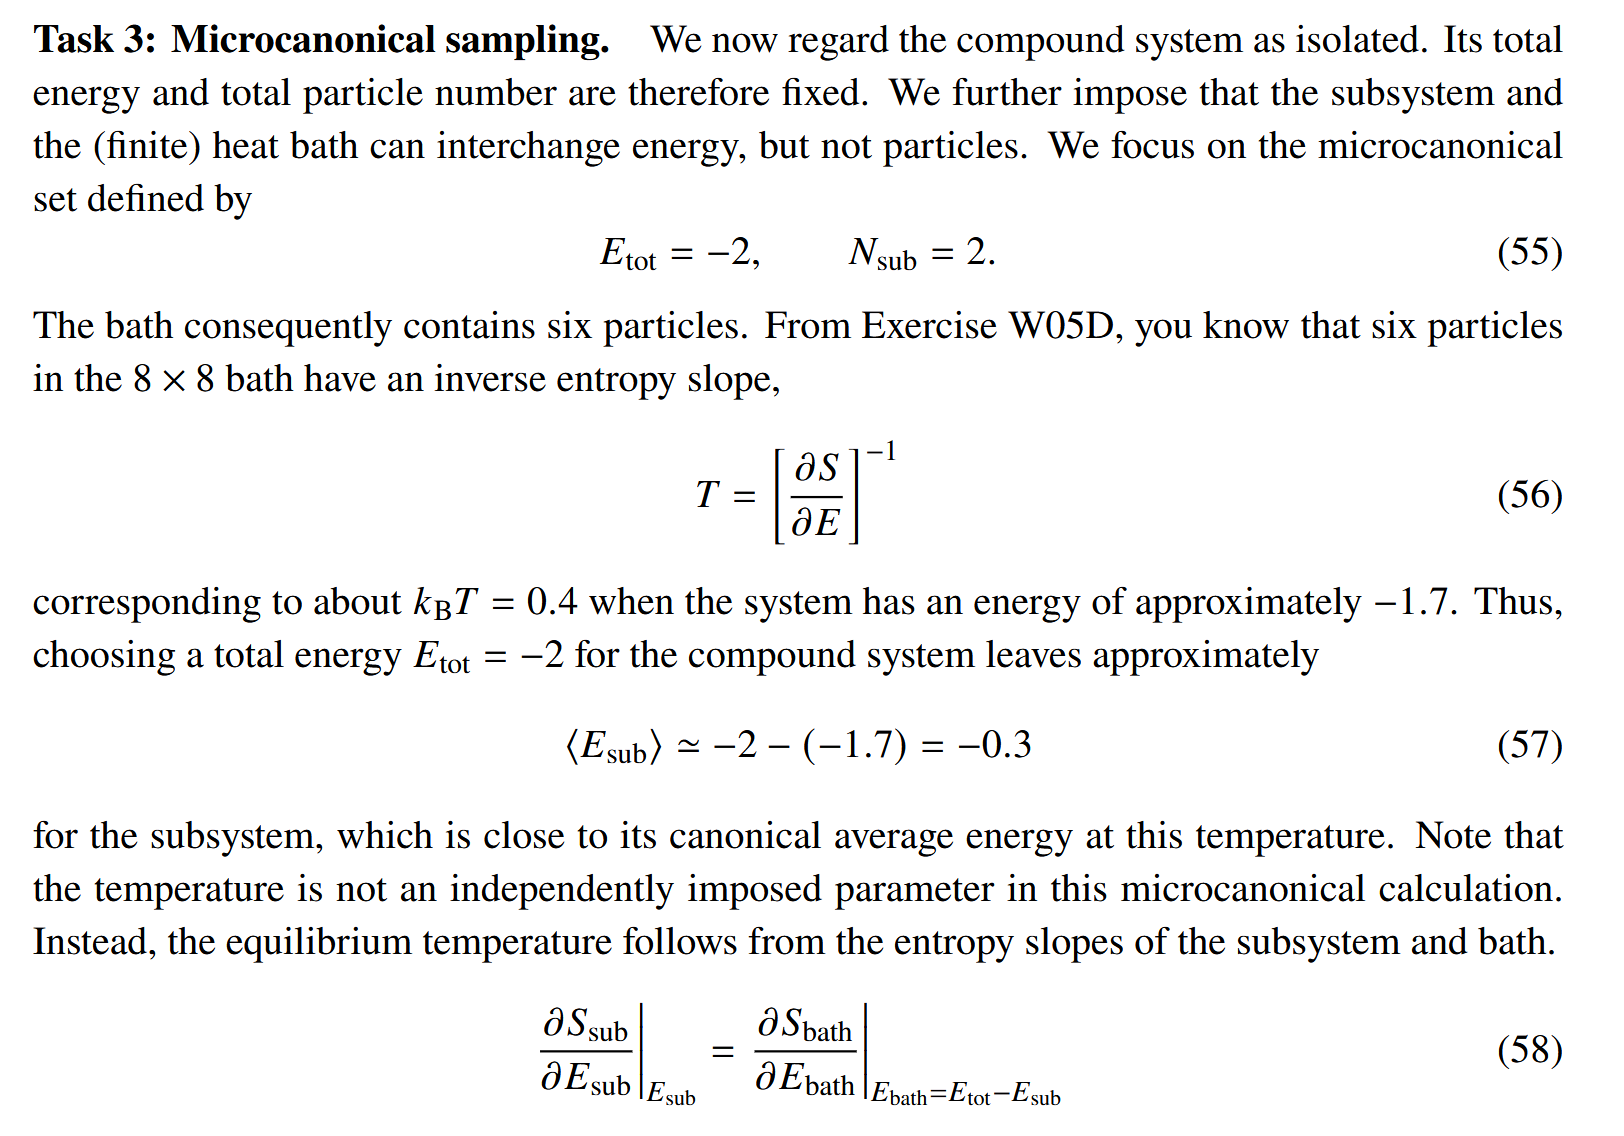
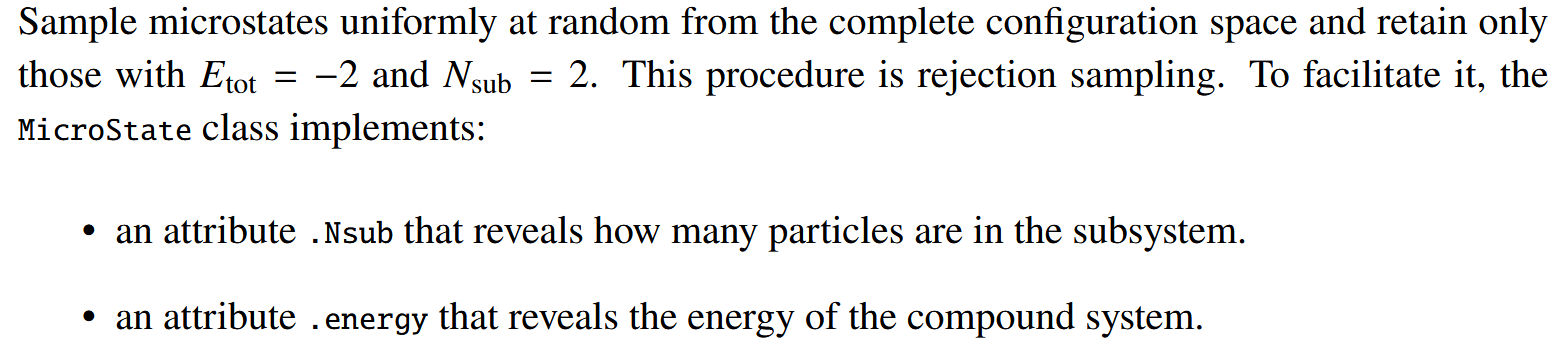
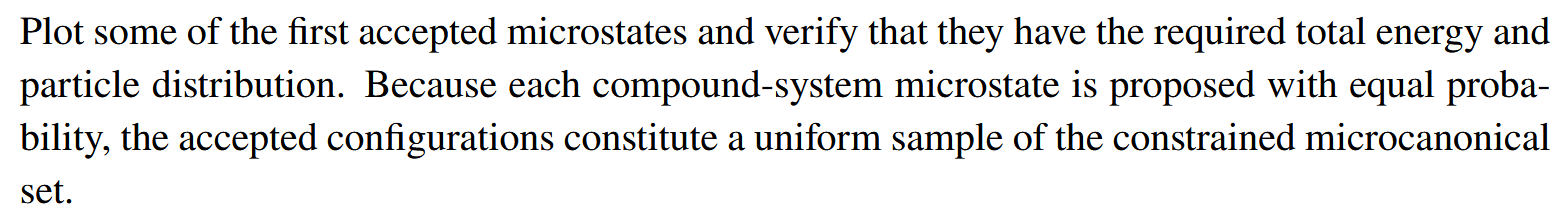
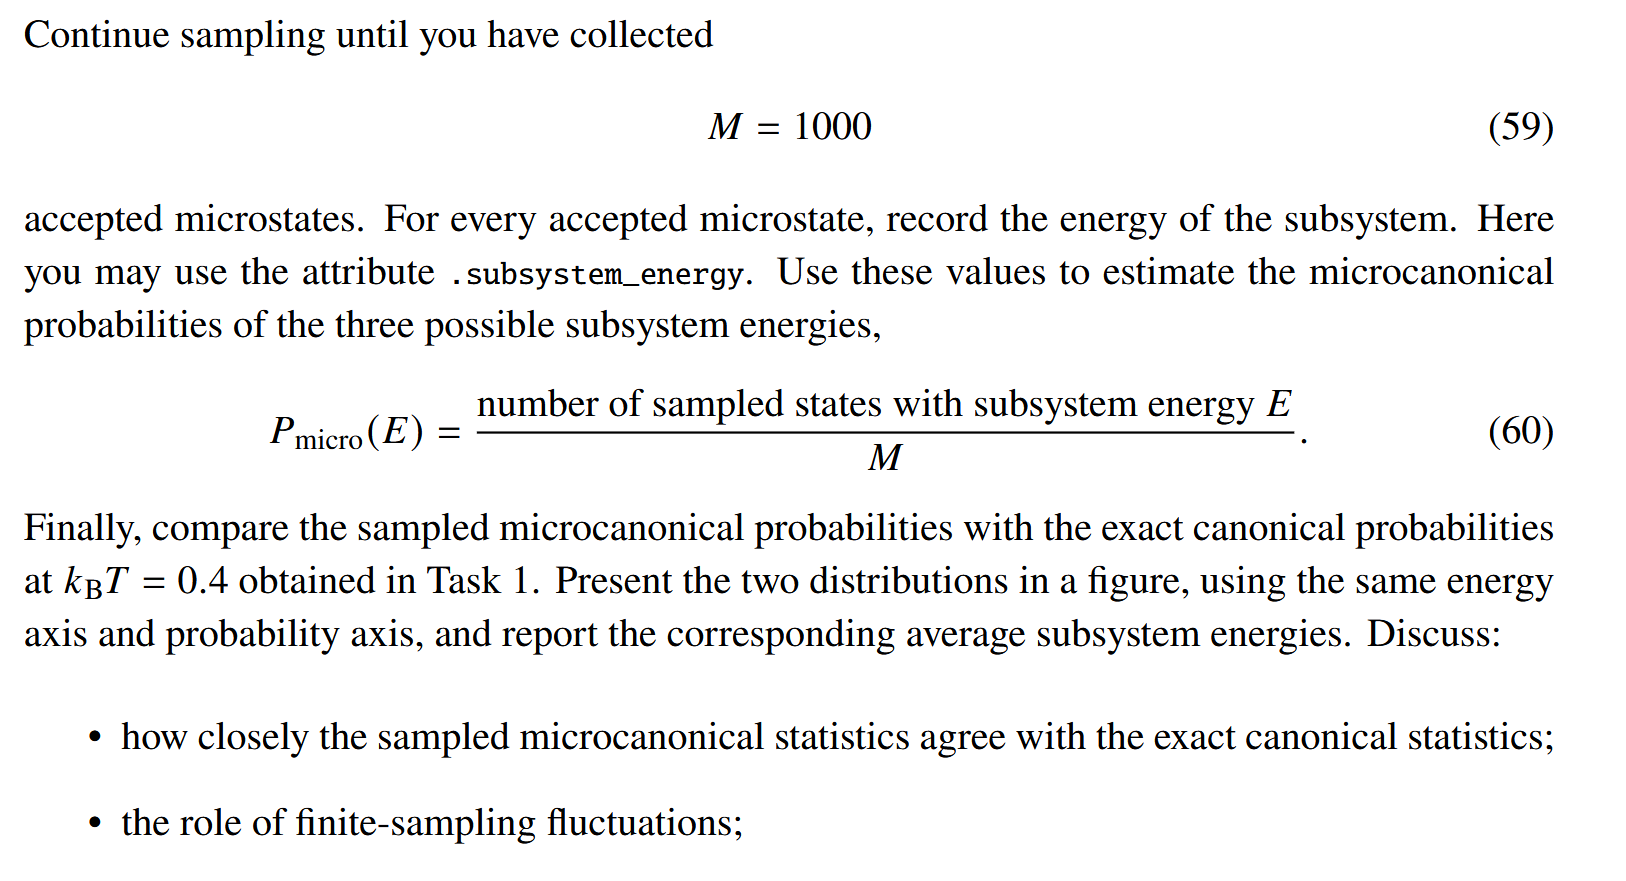
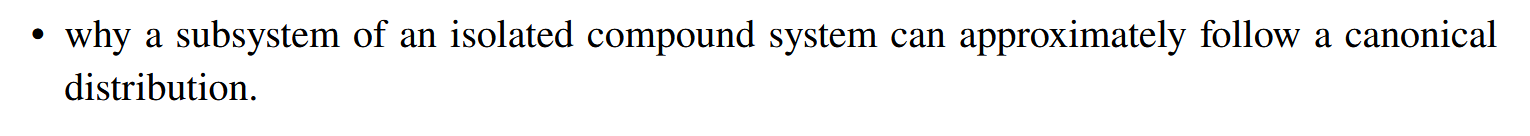

In [39]:
acc_states = []
while len(acc_states) < 1000:
    m = MicroState()
    if m.energy == -2.0 and m.Nsub == 2:
        acc_states.append(m)

M = len(acc_states)

P(-0.5) = 0.54 | P(-0.2) = 0.23 | P(-0.0) = 0.23 | 
Exact probabilities:  0.58 | 0.21 | 0.22 | 

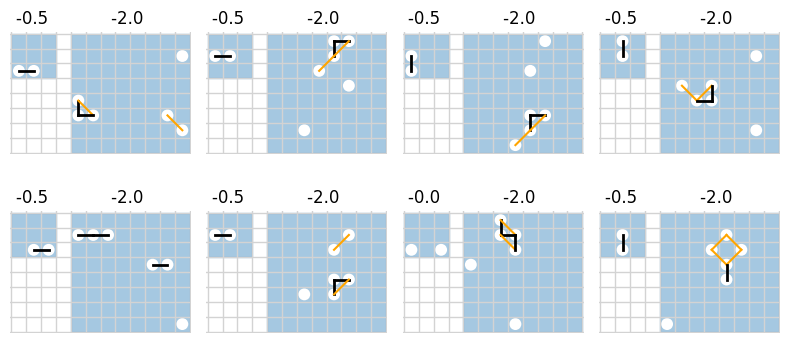

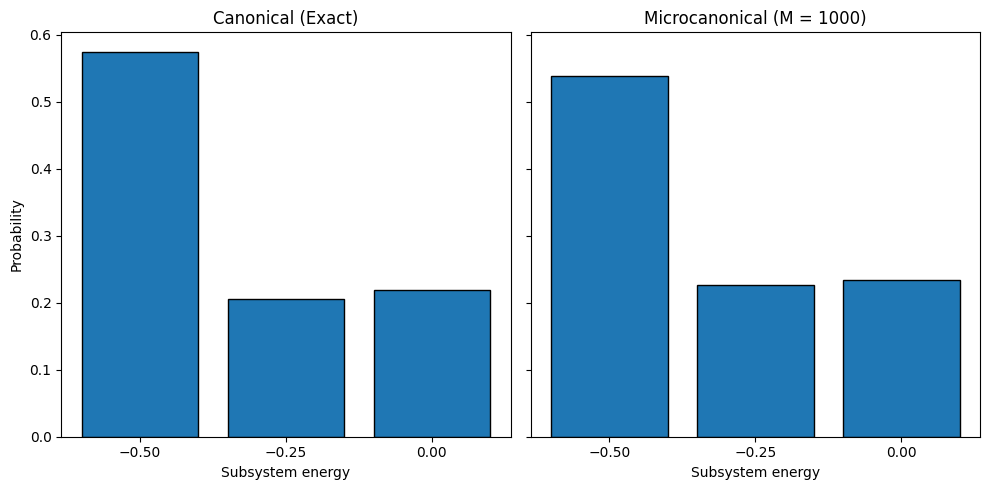

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.flatten()

for m, ax in zip(acc_states[:len(axes)], axes):
    m.plot(ax)
    ax.set_title(f'{m.subsystem_energy}            {m.energy}        ')
plt.tight_layout()

levels, counts = np.unique([s.subsystem_energy for s in acc_states], return_counts=True)
P = np.array(counts) / M
for e, p in zip(levels, P):
    print(f'P({e:.1f}) = {p:.2f}', end=' | ')

print('\nExact probabilities: ', end=' ')
for p in probabilities:
    print(f'{p:.2f}', end=' | ')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax1.set_title('Canonical (Exact)')
ax1.bar(levels, probabilities, width=0.2, align='center', edgecolor='black')
ax1.set_xlabel('Subsystem energy')
ax1.set_ylabel('Probability')
ax1.set_xticks(levels)

ax2.set_title(f'Microcanonical (M = {M})')
ax2.bar(levels, P, width=0.2, align='center', edgecolor='black')
ax2.set_xlabel('Subsystem energy')
ax2.set_xticks(levels)

plt.tight_layout()

The agreement between sampled microcanonical statistics and exact canonical statistics hinges on the concept of ensemble equivalence. In statistical mechanics, an isolated system with a fixed total energy (microcanonical) and a system connected to a heat bath at a fixed temperature (canonical) will yield the same macroscopic thermodynamic properties—like average energy or pressure—provided the system is large enough. If you are comparing a sampled microcanonical dataset to exact canonical formulas, any deviations you observe will primarily stem from the system being too small (where boundary effects and fluctuations are significant) rather than a flaw in the statistical theory itself.

Finite-sampling fluctuations represent the statistical noise introduced when you cannot exhaustively count every possible microstate. When you sample uniformly instead of enumerating the millions of exact configurations, your sampled counts $n(E)$ only approximate the true multiplicity $\Omega(E)$. Because these counts obey counting statistics, the relative error in any energy bin scales as $1/\sqrt{n}$. In bins with very few sampled states (like the extreme low or high energy tails), this noise is severe, leading to jagged histograms, erratic derivatives, and large spikes when calculating thermodynamic variables like temperature from the sampled entropy.

A subsystem of an isolated compound system follows a canonical distribution because the rest of the compound system acts as a thermal reservoir. If you have a massive, isolated compound system, its total energy $E_{\text{tot}}$ is strictly conserved (a microcanonical setup). If you conceptually carve out a small subsystem, this subsystem can freely exchange energy with the massive remaining environment (the bath). The probability of finding the small subsystem with a specific energy $E$ is proportional to the number of ways the *rest* of the environment can arrange itself with the leftover energy $E_{\text{tot}} - E$. Because the environment is so large, this multiplicity decays exponentially as it gives up energy to the subsystem, naturally yielding the Boltzmann factor $e^{-E/k_B T}$. Thus, even though the whole universe is isolated, the small piece inside behaves exactly as if it is submerged in a constant-temperature canonical bath.